In [10]:
import pandas as pd
import glob
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import ast
import re

# Find all CSV files that start with "Node"
files = glob.glob("Node*.csv")
node_data = {}

# Load all files into memory with a progress bar
for file in tqdm(files, desc="Loading CSVs"):
    # Extracts only the digits that come directly after 'Node'
    match = re.search(r'Node(\d+)', file)
    
    if match:
        node_number = match.group(1) # This stores "1", "2", "10", etc.
        node_data[node_number] = pd.read_csv(file)

Loading CSVs:   0%|          | 0/9 [00:00<?, ?it/s]

Loading CSVs: 100%|██████████| 9/9 [00:05<00:00,  1.69it/s]


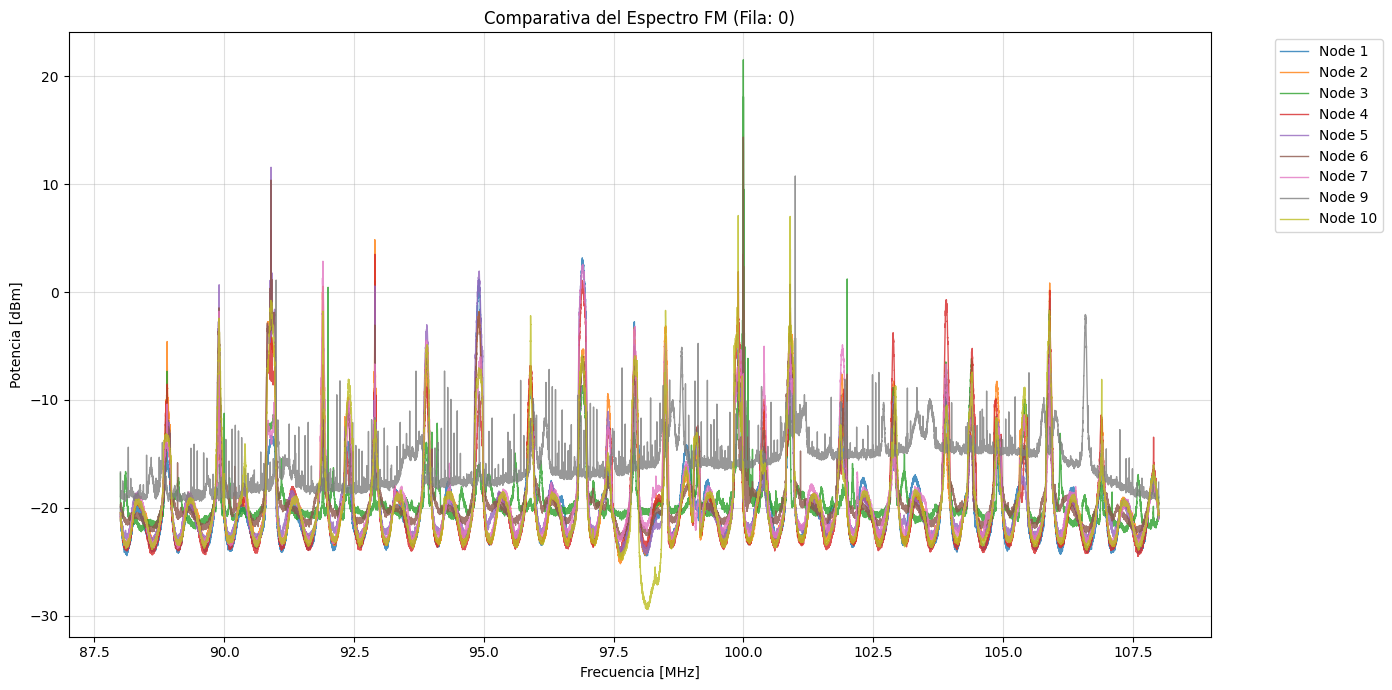

In [11]:
ROW_PLOT = 0  # Changed to plot the first row

# Define the target nodes (1 through 10, excluding 8)
target_nodes = [str(i) for i in range(1, 11) if i != 8]

plt.figure(figsize=(14, 7))

for node_number in target_nodes:
    # Check if the node was successfully loaded in the first step
    if node_number in node_data:
        df = node_data[node_number]
        
        # Extract the list of the specified row
        pxx = ast.literal_eval(df['pxx'].iloc[ROW_PLOT])
        frecuencias = np.linspace(88, 108, len(pxx))
        
        plt.plot(frecuencias, pxx, label=f"Node {node_number}", linewidth=1, alpha=0.8)
    else:
        print(f"Warning: Node {node_number} not found in the loaded data.")

plt.title(f"Comparativa del Espectro FM (Fila: {ROW_PLOT})")
plt.xlabel("Frecuencia [MHz]")
plt.ylabel("Potencia [dBm]")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()